# Bacis of Clustering
## An Introduction to K-Means

Clustering is primarily a method of finding subgroups (or clusters) in a dataset. It uses the data provided to classify things based on how similar they are. Of course, we must then define what is means for something to be similar or different. K-Means, as our first method, is how you do that using the mean.

Let's say, for example, that we have $n$ observations, each with $p$ features (number of measurable things). For example, consider doing 5 unique medical tests and using the results to see which disease group that those test results most likely groups with. This can very significantly aid in diagnosing more common diseases. Clustering, thus, is one tool that lets us find these common groups.

We should note that clustering is **unsupervised**. This means that it has no knowledge of the underlying structure, rather than predict an outcome to a known action. When you know what is happening in the background (such as a formula or predicting disease outcome), this is called **supervised** learning.

Clustering itself is used in a wide variety of fields: Medicine and disease prediction, fluids, experimental sciences, biology for species classification, machine learning and AI development, and much, much more.

One of the most, if not the actual most, well-known method(s) is _$K$-Means_ clustering. Here, we seek to group our data into a pre-defined number of clusters (hence the $K$ in $K$-Means).

Let us use $C_k$ to refer to cluster $k$, so $C_1$ is the first cluster and $C_K$ is the last. As we build our clusters, we will follow 2 rules for $K$-Means:
1. No singular item may be part of two clusters. Thus, $C_k \cap C_{q'} = \emptyset$ for all $k \neq q$.
2. Each datapoint belongs to a cluster. Thus $C_1 \cup C_2 \cup \dots \cup C_K = \{ 1, \dots, n\}$.

If datapoint $i$ is in cluster, let's say, 7, then we say $i \in C_7$ and $i \not\in C_6$.

This is the basic idea of $K$-Means. Next, we will discuss exactly how we do this grouping.

## Performing a K-Means Clustering

To perform $K$-Means clustering, we seek to minimize the **within-cluster variation**. That means if we were to measure some type of distance between points, each cluster's distance between items that are in the cluster is as small as possible.

You already know one simple way of calculating distance in 2D: Subtract each component, square, and sum. For example, consider $X = (x_1, x_2)$ and $Y = (y_1, y_2)$. Then, the distance between these two terms is:
$$ d(X,Y) = \sqrt{(x_1 - y_2)^2 + (x_2 - y_2)^2}$$

More generally, for $n$ things with $p$ components inside of cluster $k$, so $X = (x_1, x_2, \dots, x_p)$, we can measure the total distance as
$$ W(C_k) = \sum_{X, Y \in C_k} \sum_{j=1}^p (x_j - y_j)^2$$

For example. consider the following 4 things we would want to find the positioning of. We can take these as $ \{ (1,1), (1,2), (8,8), (8,9)\}$. Just by looking at this, it's clear that the first two are most similar, as are the last two. This gives two clear groups. So, let's try the formula on these groups! First, we will group them together:
$$C_1 = \{ (1,1), (1,2)\}$$
$$C_2 = \{ (8,8), (8,9)\}$$

Measuring the distance, we see that
$$ W(C_1) = (1-1)^2 + (1-2)^2 = 1$$

With the same answer for $C_2$. Let's try this versus a "bad" grouping:
$$C_1 = \{ (1,1), (8,8)\}$$
$$C_2 = \{ (1,2), (8,9)\}$$

Measuring the distance on these "bad" groups, we get:
$$W(C_1) = (1-8)^2 + (1-8)^2 = 98$$

Thus, $K$-Means as an algorithm can be written as
$$ \text{Minimize}_{C_1, \dots, C_K} \left\{\sum_{X, Y \in C_k} \sum_{j=1}^p (x_j - y_j)^2\right\}$$

The harder part, then, is finding an algorithm that actually does this! This is something we will provide next.

## An Algorithm For $K$-Means
Now, we will try to find a good algorithm to solve this. We will pull a diagram from [1] to do this. Let us start with some random data:

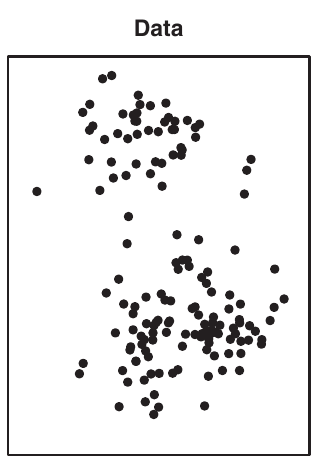


Perfect! Next, we are lacking something: We don't have anywhere to start! We can't minimize within-group distances if we don't know which group something belongs to to begin with. So, let's define step 1:
1. For each datapoint, randomly assign it to one cluster, from 1 to $K$.

Let's do that with our data:

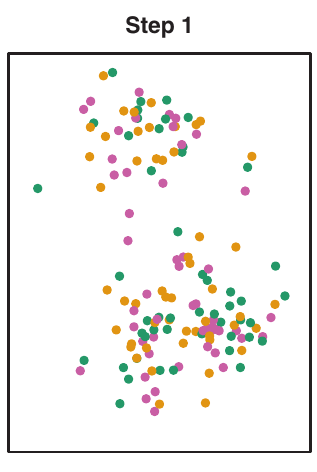

Now, of course, this grouping sucks, but we haven't actually done anything yet - We have literally only assigned groups randomly. For each group, we can calculate its within-group distance very easily, but we now have a new problem: We need some way to assign some point to a **better** (or closer) group. Thus, we now present step 2:

2. (a) For each cluster, compute its mean (or "centroid") as the mean of all the values in the group.

Remember our example above? Let's take the old $C_1 = \{ (1,1), (8,8)\}$, then the "centroid" of this group is at the mean of each component: $$\mu_1 = \bigl( (1+8)/2, (1+8)/2\bigr) = (4.5,4.5)$$

Once again, let's do that with our example data:

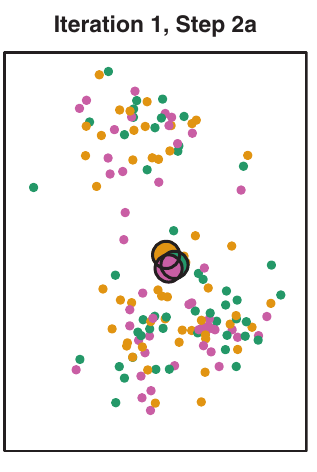

Perfect, we now have a mean! It's finally time to reassign points to a better group. In this case, we have our final rule:

2. (b) For each point, reassign it to the group with the closest mean.

This is quite simple as well! Thus, we once again will do it to our data:

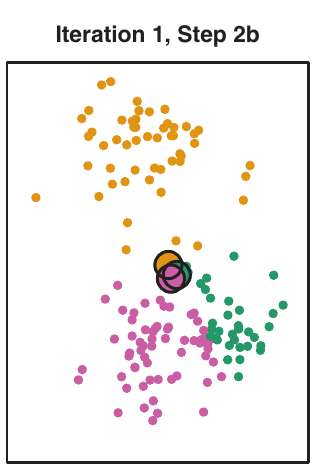

Then, all that's left is to repeat steps 2(a) and 2(b) until the groups stop changing! As before, we do this to our data to get:

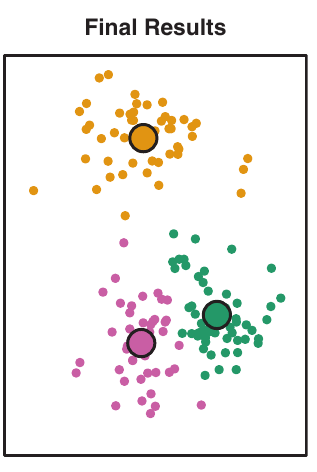

## Potential Problems

Alright, now we should discuss some potential problems with this method. One of these is the most common for these types of simple minimization algorithms:

- What happens if the minimum is local, meaning that it isn't the best possible minimum but the algorithm has gotten stuck and stopped changing?

This is often handled by using a more complicated algorithm, which we will save as an exercise for you all: K-Means++.

There are other, less serious problems:

- $K$-Means is deterministic, meaning elements only belong to one group with a 0% chance of being in another group, making it hard to improve when you get more data without starting over.

- The value of $K$ itself is manual. If you want to find the best $K$, you need to use other tools on your own.

- If one field is naturally larger than another (such as how height in meters maxes out at 2, but weight in kg maxes out well above 100), then one piece dominates and is how groups are determined.

This last one is the easiest to handle: For every datapoint, we scale them from 0 to 1. To do so, for each segment, $j$, we use the following formula:
$$ x_j = \frac{x_j - min(X_j)}{max(X_j) - min(X_j)}$$

Or, more simply: For each datapoint segment $j$, subtract the minimum $x_j$ in the entire dataset, and divide by the max $x_j$ minus the min $x_j$.

## Your Turn!
### Task 1 - Programming $K$-Means
Now, its your turn! Below, we have put the shell for a $K$-Means algorithm. What you have to do is fill in the blanks to make it work!

The data we have provided is designed for **four groups** (or centers), so we have hard-set $k=1$. In real data, you will need to try multiple different $k$ values!

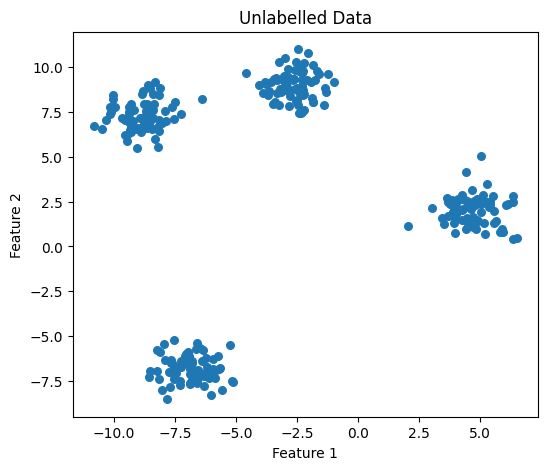

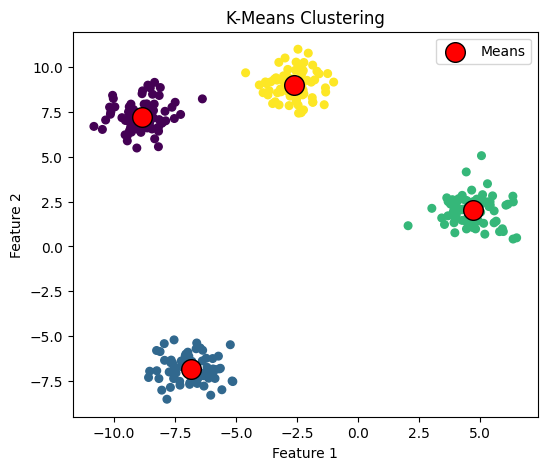

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# ------------------------------
# Fixed dataset
# ------------------------------
np.random.seed(1)

X, true_labels = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

k = 4

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Unlabelled Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# ------------------------------
# Plotting function
# ------------------------------

def plot_k_means(X, labels, means):
    plt.figure(figsize=(6, 5))

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=labels,
        s=30,
        cmap="viridis"
    )

    plt.scatter(
        means[:, 0],
        means[:, 1],
        c="red",
        s=200,
        marker="o",
        edgecolor="black",
        label="Means"
    )

    plt.title("K-Means Clustering")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

# ------------------------------
# Your task: implement K-Means
# ------------------------------

def k_means(X, k, max_iters=100):
    """
    Perform K-Means clustering here!
    """

    n_points = X.shape[0]
    n_features = X.shape[1]

    # --------------------------------
    # Step 1: Assign random locations
    # --------------------------------
    # Randomly assign each point to one of the k clusters.
    #
    # labels should have shape (n_points,)
    # Each entry should be an integer from 0 to k - 1.

    labels = np.random.randint(0, k, size=n_points) # Randomly generate an array of labels

    # --------------------------------
    # Step 1b: Normalize your data
    # --------------------------------
    # Ensure that all of the data ranges from only 0 to 1.
    #
    # The blobs are 2D, so you can normalize X[0] and X[1].

    X_norm = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0)) # Normalize

    for iteration in range(max_iters):

        # --------------------------------
        # Step 2a: Get means
        # --------------------------------
        # For each cluster, compute the mean of all points
        # currently assigned to that cluster.
        #
        # means should have shape (k, n_features).

        means = np.zeros((k, n_features)) # Initialize means matrix
        
        for i in range(k): # For each cluster
            cluster = X_norm[labels == i] # Form a "cluster" 
            if len(cluster) > 0: # If the cluster is not empty
                means[i] = np.mean(cluster, axis=0) # Take the mean of the cluster and store
            else: # If the cluster is empty
                means[i] = X_norm[np.random.randint(0, n_points)] # Assign a random point as the new mean


        # --------------------------------
        # Step 2b: Assign to nearest mean
        # --------------------------------
        # For each point, compute which mean is closest.
        #
        # new_labels should have shape (n_points,).

        new_labels = np.zeros(n_points) # Initialize new labels

        for i in range(n_points): # For each data point
            dists = np.zeros(k) # Initialize distances for each mean
            for j in range(k): # For each cluster mean
                dists[j] = np.linalg.norm(X_norm[i] - means[j]) # Calculate the distance from the data point to the mean
            min_pt = np.min(dists) # Find the smallest distance
            new_labels[i] = np.argmin(dists) # Assign the data point to the cluster corresponding to the smallest distance


        # --------------------------------
        # Stop if assignments did not change
        # --------------------------------

        if np.array_equal(new_labels, labels):
            break

        labels = new_labels

    

    return labels, means * (X.max(axis=0) - X.min(axis=0)) + X.min(axis=0) # Return mean to original scale

# ------------------------------
# Run K-Means
# ------------------------------

labels, means = k_means(X, k, max_iters=100)

plot_k_means(X, labels, means)

### Task 2 - Finding The Best K
Next, we want you to use the code you made above, but this time given some data with less obvious groups. Don't let the "centers = 5" trick you, we have set up this data to purposefully not be 5.

What you need to do is try different values of $K$ to see which is best for this data. Bonus points if you can explain **why** through both:

1. Plotting the clusters, and
2. Printing the average within-group variation for each group for the different $K$ values!

If you want to do the "printing within-group variation" approach, we have included a "compute_variation" function below to make it easier. One thing of note: As you increase $K$, you will **always** get a smaller variation, so we recommend you look for the area where the change is effectively flatlined.

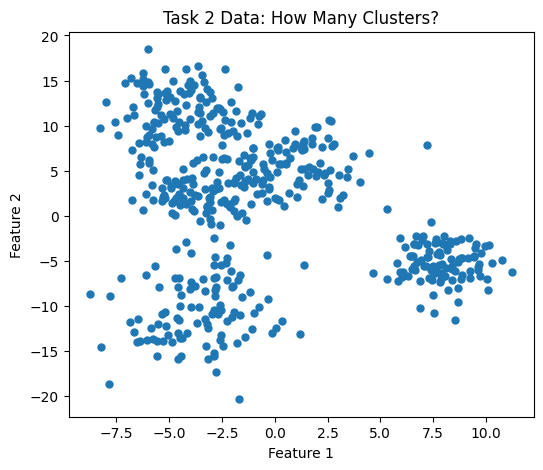

[47566.58453887 20540.71104687 10787.12249247  7819.30774341
  4568.37264785  4349.76097621  3950.10056925  3317.20059429
  3022.84658677  3330.30825087  2581.40533882  2646.71852646
  2111.90807276  2202.07623065  2115.6711271   2264.06512596
  1907.41417503  1768.05731148  1745.51988985  1741.26415517
  1444.09329351  1616.29918553  1323.99928783  1374.9016218
  1298.4905841   1367.88546636  1213.39605574  1350.76373095
  1353.96769661  1256.40255268  1189.99826279  1300.69428313
  1172.03863419  1205.06565174  1213.70541515   949.94571365
  1018.78673569   935.14688661   964.96808076   996.75062627
   952.21456457   984.36030283  1190.80155536  1037.11300986
   918.00666538   931.11193525   908.46095158   766.54202417
   934.27707621]


<Figure size 600x500 with 0 Axes>

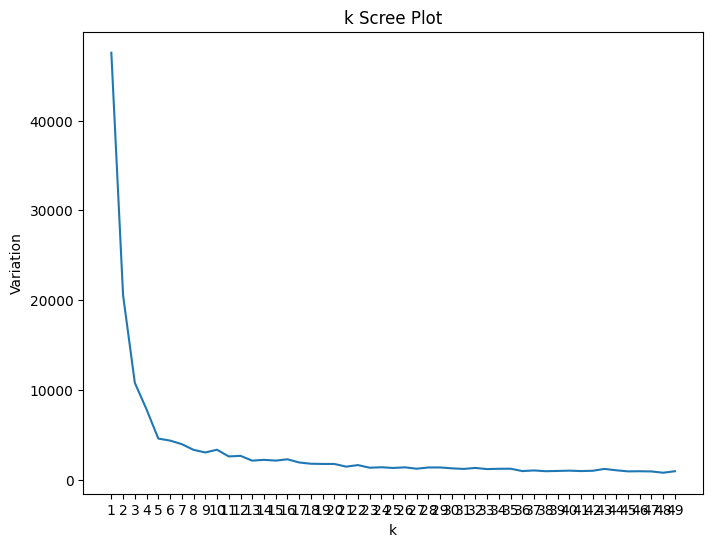

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# ------------------------------
# Task 2: Generate data
# ------------------------------

np.random.seed(10)

X2, hidden_labels = make_blobs(
    n_samples=500,
    centers=5,
    cluster_std=[1.8, 2.2, 1.5, 2.6, 1.9],
    random_state=7
)

transformation = np.array([
    [0.8, -0.6],
    [0.4,  1.2]
])

X2 = X2 @ transformation

plt.figure(figsize=(6, 5))
plt.scatter(X2[:, 0], X2[:, 1], s=25)
plt.title("Task 2 Data: How Many Clusters?")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# ------------------------------
# Measure clustering quality
# ------------------------------

def compute_variation(X, labels, means):
    inertia = 0

    for cluster in range(len(means)):
        points_in_cluster = X[labels == cluster]

        if len(points_in_cluster) > 0:
            squared_distances = np.sum((points_in_cluster - means[cluster]) ** 2)
            inertia += squared_distances

    return inertia

# ------------------------------
# Try different values of k
# ------------------------------

max_k = 50
variation = np.zeros(max_k-1)

for k in range(1, max_k):
    labels, means = k_means(X2, k, max_iters=100)
    variation[k-1] = compute_variation(X2, labels, means)

plt.figure(figsize=(6, 5))

print(variation)

plt.figure(figsize=(8, 6))
plt.plot(range(1, max_k), variation)

plt.title("k Scree Plot")
plt.xticks(range(1, max_k))
plt.xlabel("k")
plt.ylabel("Variation")
plt.show()
    

    

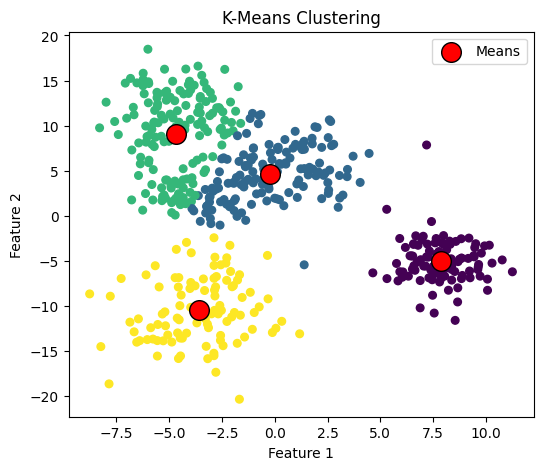

In [73]:
k = 4 # Seems like the best choice at the elbow bend

labels, means = k_means(X2, k, max_iters=100)

plot_k_means(X2, labels, means)

## Bonus Tasks!

If you finished those two tasks before our next meeting, we have two taks we want you to try and report back! Try them out and tell us how it goes:

### Bonus Task 1 - Your Own Data!
Try importing your own data and applying the above methods to it. We haven't discussed pre-processing yet, so we recommend some clean example data. If you need an example set, the following flower data is quite nice from sklearn!

```
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

X_iris = iris.data
iris_df = pd.DataFrame(X_iris, columns=iris.feature_names)

X_iris_2d = iris_df[["petal length (cm)", "petal width (cm)"]].to_numpy()
```

There's also lots of example other data, which you can access with:
```
wine = load_wine()
X_wine = wine.data
wine_df = pd.DataFrame(X_wine, columns=wine.feature_names)

cancer = load_breast_cancer()
X_cancer = cancer.data
cancer_df = pd.DataFrame(X_cancer, columns=cancer.feature_names)
```

To view the names of columes, which you can use for 2d or above clustering, you can use
```
wine_df.head()
cancer_df.head()
```

Here's some questions that you should try to answer:

1. What dataset did you use? Why?
2. Which features did you cluster on?
3. What values of $k$ did you try? Which was best?
4. Do you think the groups $K$-Means found were good?

### Bonus Task 2 - K-Means++
One huge problem with K-Means is that it can fall into a local optima, rather than the true answer. One solution to this is to use K-Means++. While K-Means++ does not solve the entire problem of local minima, it helps address it by picking points better than truely random, and otherwise it is the same.

The steps for K-Means++ are outlined here. Try to implement it **without** reading their solution! Link: https://www.geeksforgeeks.org/machine-learning/ml-k-means-algorithm/

## References
1. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). An Introduction to Statistical Learning. In Springer Texts in Statistics. Springer US. https://doi.org/10.1007/978-1-0716-1418-1

‌